In [2]:
import pandas as pd
churn_data = pd.read_csv("Churn_Modelling.csv")
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
churn_data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [6]:
churn_data = churn_data.drop(
    ['RowNumber', 'CustomerId', 'Surname'],
    axis=1
)

In [8]:
label_encoder = LabelEncoder()


churn_data['Gender'] = label_encoder.fit_transform(
    churn_data['Gender']
)


churn_data['Geography'] = label_encoder.fit_transform(
    churn_data['Geography']
)

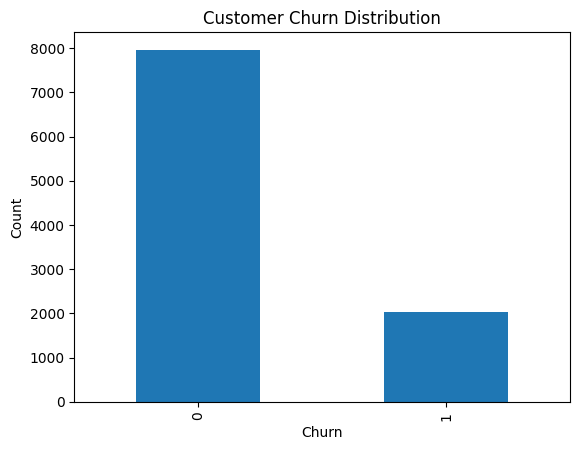

In [9]:
churn_data['Exited'].value_counts().plot(kind='bar')

plt.xlabel("Churn")
plt.ylabel("Count")
plt.title("Customer Churn Distribution")

plt.show()

In [10]:
X = churn_data.drop('Exited', axis=1)

y = churn_data['Exited']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [13]:
churn_model = LogisticRegression()

churn_model.fit(X_train, y_train)

LogisticRegression()

In [14]:
predictions = churn_model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8155


In [16]:
sample_customer = [[
    600,   # CreditScore
    1,     # Geography
    1,     # Gender
    40,    # Age
    3,     # Tenure
    60000, # Balance
    2,     # NumOfProducts
    1,     # HasCrCard
    1,     # IsActiveMember
    50000  # EstimatedSalary
]]

# Scale customer data
sample_customer = scaler.transform(sample_customer)

# Predict churn
prediction = churn_model.predict(sample_customer)

if prediction[0] == 1:
    print("Customer is likely to leave")
else:
    print("Customer is likely to stay")

Customer is likely to stay


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [17]:
import pickle

pickle.dump(churn_model, open("churn_model.pkl", "wb"))